### ************Credit Card Fraud Detection************

🚀 Steps
1️⃣ Load & Explore Data
2️⃣ Train Isolation Forest
3️⃣ Predict Anomalies
4️⃣ Evaluate Results
5️⃣ Visualize Anomalies

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


# We will use the Credit Card Fraud Dataset from Kaggle.
# 👉 Download from Kaggle

# 🔹 Dataset Overview:

# Contains 284,807 transactions
# Features V1 to V28 (extracted via PCA)
# Class: 0 = Normal Transaction, 1 = Fraudulent Transaction
# Most transactions are normal (imbalanced dataset)

In [ ]:
# Load data
df = pd.read_csv('D:\creditcard.csv')

# Check data info
print(df.info())

# Show first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
# Drop unnecessary columns (e.g., 'Time' is not useful for anomaly detection)
df = df.drop(columns=["Time"], axis=1)

# Standardize the 'Amount' column
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Define feature columns (excluding target variable 'Class')
feature_columns = df.drop(columns=["Class"]).columns  # Save the exact feature names

In [14]:
# Train Isolation Forest on selected features
model = IsolationForest(n_estimators=100, contamination=0.001, random_state=42)
model.fit(df[feature_columns])  # Ensure consistent feature set

IsolationForest(contamination=0.001, random_state=42)

In [15]:
# Use the same features for prediction
df["Anomaly_Score"] = model.decision_function(df[feature_columns])
df["Anomaly"] = model.predict(df[feature_columns])  # -1 = anomaly, 1 = normal

# Convert -1 (fraud) and 1 (normal) to human-readable labels
df["Anomaly_Label"] = df["Anomaly"].map({1: "Normal", -1: "Fraud"})

In [16]:
from sklearn.metrics import classification_report

# Convert -1 (fraud) and 1 (normal) into 0 (normal) and 1 (fraud) to match actual labels
y_pred = np.where(df["Anomaly"] == -1, 1, 0)  # Convert -1 to 1 (fraud) and 1 to 0 (normal)
y_true = df["Class"].values  # Actual labels

# Print classification report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.37      0.21      0.27       492

    accuracy                           1.00    284807
   macro avg       0.68      0.61      0.63    284807
weighted avg       1.00      1.00      1.00    284807



# 🔹 Key Metrics

# Precision: How many detected frauds are actual frauds?
# Recall: How many actual frauds were detected?
# F1-score: Balance of precision & recall.

C:\Users\Harsh\AppData\Local\Temp\ipykernel_6224\1252166033.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Anomaly_Label", palette={"Normal": "blue", "Fraud": "red"})


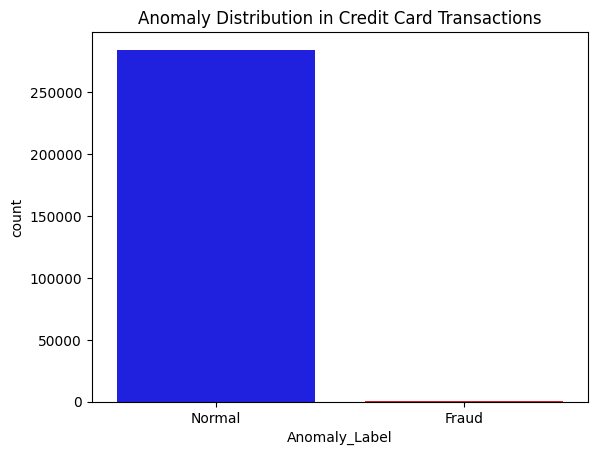

In [17]:
sns.countplot(data=df, x="Anomaly_Label", palette={"Normal": "blue", "Fraud": "red"})
plt.title("Anomaly Distribution in Credit Card Transactions")
plt.show()

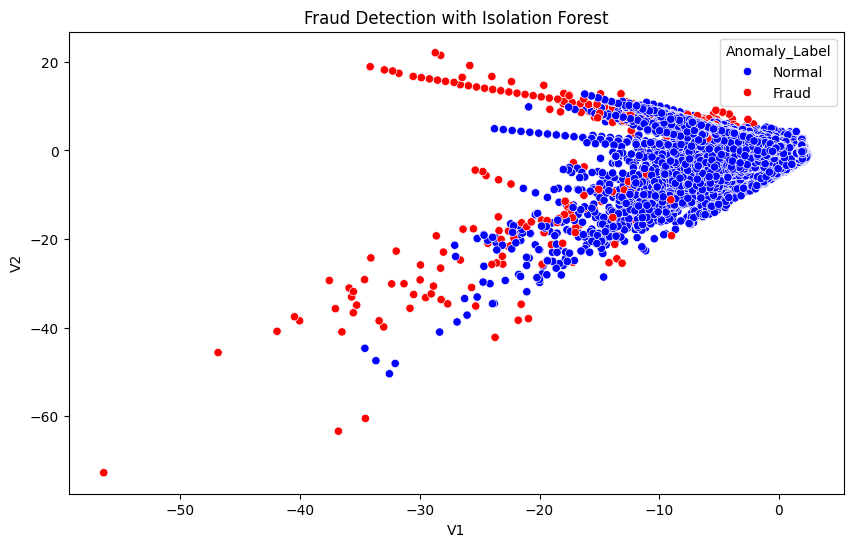

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="V1", y="V2", hue="Anomaly_Label", palette={"Normal": "blue", "Fraud": "red"})
plt.title("Fraud Detection with Isolation Forest")
plt.show()